<a href="https://colab.research.google.com/github/Dreeck/ProyectosML/blob/ProyectoFinal/clasificacion_y_regresion_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import io
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score)
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix


In [ ]:
uploaded = files.upload()


Saving data.csv to data.csv


In [ ]:
!head -n 10 data.csv # Mostrar las primeras 10 líneas del archivo


"id","diagnosis","radius_mean","texture_mean","perimeter_mean","area_mean","smoothness_mean","compactness_mean","concavity_mean","concave points_mean","symmetry_mean","fractal_dimension_mean","radius_se","texture_se","perimeter_se","area_se","smoothness_se","compactness_se","concavity_se","concave points_se","symmetry_se","fractal_dimension_se","radius_worst","texture_worst","perimeter_worst","area_worst","smoothness_worst","compactness_worst","concavity_worst","concave points_worst","symmetry_worst","fractal_dimension_worst",
842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,1.095,0.9053,8.589,153.4,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
842517,M,20.57,17.77,132.9,1326,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.0186,0.0134,0.01389,0.003532,24.99,23.41,158.8,1956,0.1238,0.1866,0.2416,0.186,0.275,0.08902
84300903,M,19.69,21.25,130,1203,0.10

In [ ]:
# Obtener el nombre del archivo subido
file_name = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[file_name]), quotechar='"', sep=',')

# Eliminar columnas no nombradas (como 'Unnamed: 32')
df = df.loc[:, ~df.columns.str.contains('Unnamed')]

# Mostrar la tabla
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Clasificación

In [ ]:
# Codificar la variable objetivo (M=1, B=0)
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])  # M=1, B=0

# Separar características (X) y variable objetivo (y)
X_class = df.drop('diagnosis', axis=1)
y_class = df['diagnosis']

# Dividir datos en entrenamiento (70%) y prueba (30%)
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
X_class, y_class, test_size=0.3, random_state=42, stratify=y_class)


# Escalar características (importante para SVM, redes neuronales, etc.)
scaler_class = StandardScaler()
X_train_class_scaled = scaler_class.fit_transform(X_train_class)
X_test_class_scaled = scaler_class.transform(X_test_class)


In [ ]:
from sklearn.decomposition import PCA

# Aplicar PCA
pca = PCA(n_components=0.95)  # 95% de varianza
X_train_pca = pca.fit_transform(X_train_class_scaled)
X_test_pca = pca.transform(X_test_class_scaled)

# Ver varianza explicada
print("Varianza explicada por componente:", pca.explained_variance_ratio_)
print("Número de componentes seleccionados:", pca.n_components_)


Varianza explicada por componente: [0.42287816 0.18606789 0.09470143 0.06467042 0.054257   0.04008306
 0.03197906 0.02080001 0.01450775 0.01225086 0.01149246]
Número de componentes seleccionados: 11


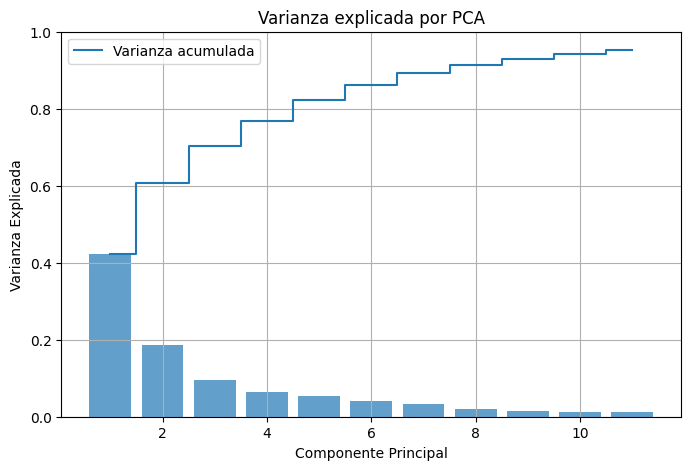

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, alpha=0.7)
plt.step(range(1, len(pca.explained_variance_ratio_)+1), np.cumsum(pca.explained_variance_ratio_), where='mid', label='Varianza acumulada')
plt.xlabel('Componente Principal')
plt.ylabel('Varianza Explicada')
plt.title('Varianza explicada por PCA')
plt.legend()
plt.grid(True)
plt.show()


Cada barra representa cuánta información aporta cada componente principal. Por ejemplo, la primera barra (Componente 1) suele ser la más alta porque explica la mayor parte de la información.

Muestra la suma acumulada de la información que aportan los componentes. Por ejemplo, si la línea llega al 80% en el componente 3, eso significa que los primeros 3 componentes explican el 80% de toda la información

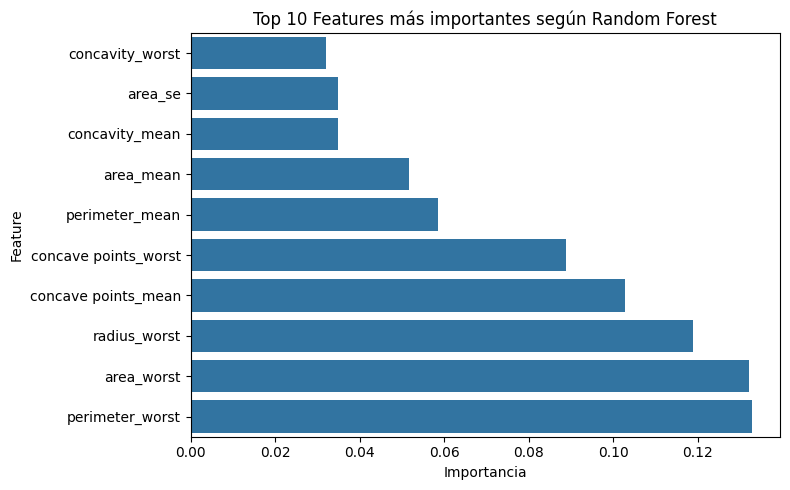

In [ ]:

rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42)
rf.fit(X_train_class_scaled, y_train_class)
importancias = rf.feature_importances_
top_10 = importancias.argsort()[-10:]

# Obtener nombres de columnas del conjunto de clasificación original
feature_names = X_class.columns[top_10]

plt.figure(figsize=(8,5))
sns.barplot(x=importancias[top_10], y=feature_names)
plt.xlabel('Importancia')
plt.ylabel('Feature')
plt.title('Top 10 Features más importantes según Random Forest')
plt.tight_layout()
plt.show()


In [ ]:
# 1. Usar datos originales escalados (sin PCA)
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
rf.fit(X_train_class_scaled, y_train_class)

# 2. Evaluar
y_pred = rf.predict(X_test_class_scaled)
print("--- Random Forest (sin PCA) ---")
print(f"Accuracy: {accuracy_score(y_test_class, y_pred):.4f}")
print(classification_report(y_test_class, y_pred))

# 3. Selección de features por importancia
importancias = rf.feature_importances_
top_10 = importancias.argsort()[-10:]
X_train_top10 = X_train_class_scaled[:, top_10]
X_test_top10 = X_test_class_scaled[:, top_10]

rf_top10 = RandomForestClassifier(random_state=42)
rf_top10.fit(X_train_top10, y_train_class)
y_pred_top10 = rf_top10.predict(X_test_top10)
print("\n--- Random Forest (Top 10 Features) ---")
print(f"Accuracy: {accuracy_score(y_test_class, y_pred_top10):.4f}")
print(classification_report(y_test_class, y_pred_top10))


--- Random Forest (sin PCA) ---
Accuracy: 0.9708
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       107
           1       1.00      0.92      0.96        64

    accuracy                           0.97       171
   macro avg       0.98      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171


--- Random Forest (Top 10 Features) ---
Accuracy: 0.9532
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       107
           1       0.97      0.91      0.94        64

    accuracy                           0.95       171
   macro avg       0.96      0.94      0.95       171
weighted avg       0.95      0.95      0.95       171



In [ ]:
models_class = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "SVM": SVC()
}


In [ ]:
for name, model in models_class.items():
    model.fit(X_train_class_scaled, y_train_class)
    y_pred_class = model.predict(X_test_class_scaled)
    print(f"--- {name} ---")
    print(f"Accuracy: {accuracy_score(y_test_class, y_pred_class):.4f}")
    print(classification_report(y_test_class, y_pred_class))


--- Logistic Regression ---
Accuracy: 0.9708
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       107
           1       0.98      0.94      0.96        64

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171

--- SVM ---
Accuracy: 0.9649
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       107
           1       1.00      0.91      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171



In [ ]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train_class_scaled, y_train_class)

print(f"Mejores hiperparámetros: {grid_search.best_params_}")
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test_class_scaled)

print("\n--- Random Forest Optimizado ---")
print(f"Accuracy: {accuracy_score(y_test_class, y_pred_best_rf):.4f}")
print(classification_report(y_test_class, y_pred_best_rf))
print("-" * 30 + "\n")


Mejores hiperparámetros: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

--- Random Forest Optimizado ---
Accuracy: 0.9766
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       107
           1       1.00      0.94      0.97        64

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171

------------------------------



# Regresion

In [ ]:
cols_to_drop_reg = [
    'diagnosis', 'radius_mean',
    'perimeter_mean', 'area_mean',
    'radius_se', 'perimeter_se', 'area_se',
    'radius_worst', 'perimeter_worst', 'area_worst'
]
X_reg = df.drop(cols_to_drop_reg, axis=1)
y_reg = df['radius_mean']

print("Características utilizadas para la regresión:")
print(X_reg.columns.tolist())


Características utilizadas para la regresión:
['id', 'texture_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'texture_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'texture_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [ ]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

# Escalar las características
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

models_reg = {
    "Regresion lineal": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(random_state=42)
}


In [ ]:
for name, model in models_reg.items():
    model.fit(X_train_reg_scaled, y_train_reg)
    y_pred_reg = model.predict(X_test_reg_scaled)
    mse = mean_squared_error(y_test_reg, y_pred_reg)
    r2 = r2_score(y_test_reg, y_pred_reg)

    print(f"--- {name} ---")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"R-squared (R²): {r2:.4f}")
    print("-" * 30 + "\n")


--- Regresion lineal ---
Mean Squared Error (MSE): 1.3215
R-squared (R²): 0.8918
------------------------------

--- Random Forest Regressor ---
Mean Squared Error (MSE): 1.5042
R-squared (R²): 0.8768
------------------------------



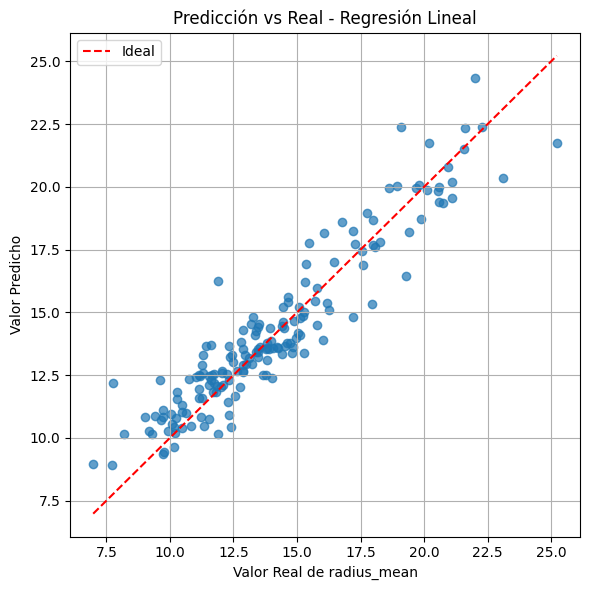

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.7)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', label='Ideal')
plt.xlabel('Valor Real de radius_mean')
plt.ylabel('Valor Predicho')
plt.title('Predicción vs Real - Regresión Lineal')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


En este gráfico, la mayoría de los puntos están cerca de la línea, lo que indica que el modelo tiene buen poder predictivo.

La dispersión alrededor de la línea muestra el error de predicción: cuanto más lejos está un punto, mayor es el error para esa observación.

In [ ]:
lr_reg = LinearRegression()
lr_reg.fit(X_train_reg_scaled, y_train_reg)


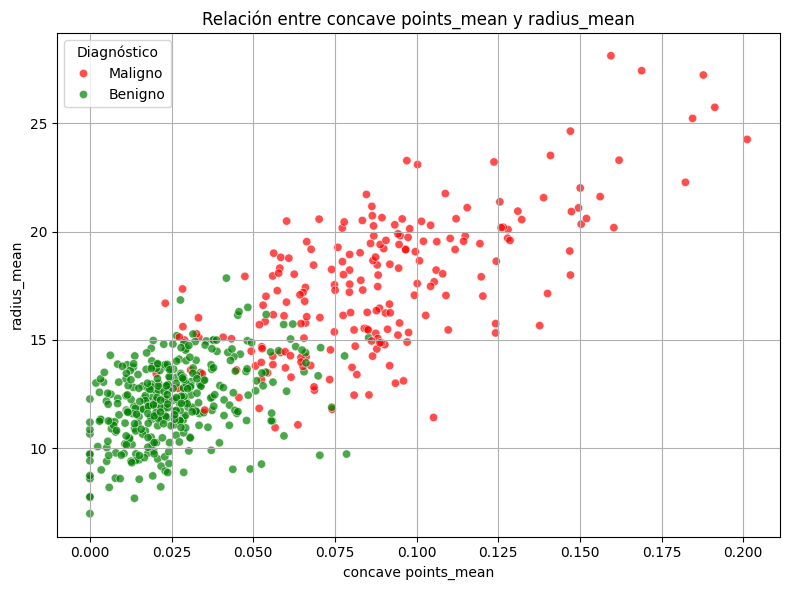

In [ ]:
df = pd.read_csv("data.csv")
df = df.drop(columns=["Unnamed: 32"], errors="ignore")
df["diagnosis"] = df["diagnosis"].map({"B": 0, "M": 1})

# Crear gráfico de dispersión corregido
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="concave points_mean",
    y="radius_mean",
    hue=df["diagnosis"].map({0: "Benigno", 1: "Maligno"}),
    palette={"Benigno": "green", "Maligno": "red"},
    alpha=0.7
)
plt.title("Relación entre concave points_mean y radius_mean")
plt.xlabel("concave points_mean")
plt.ylabel("radius_mean")
plt.legend(title="Diagnóstico")
plt.grid(True)
plt.tight_layout()
plt.show()


Los puntos rojos (malignos) tienden a agruparse en la parte superior derecha del gráfico, lo que indica que los tumores malignos tienden a tener mayor concavidad y mayor radio.

Los puntos verdes (benignos) se concentran en la parte inferior izquierda, lo que indica menor concavidad y menor radio.

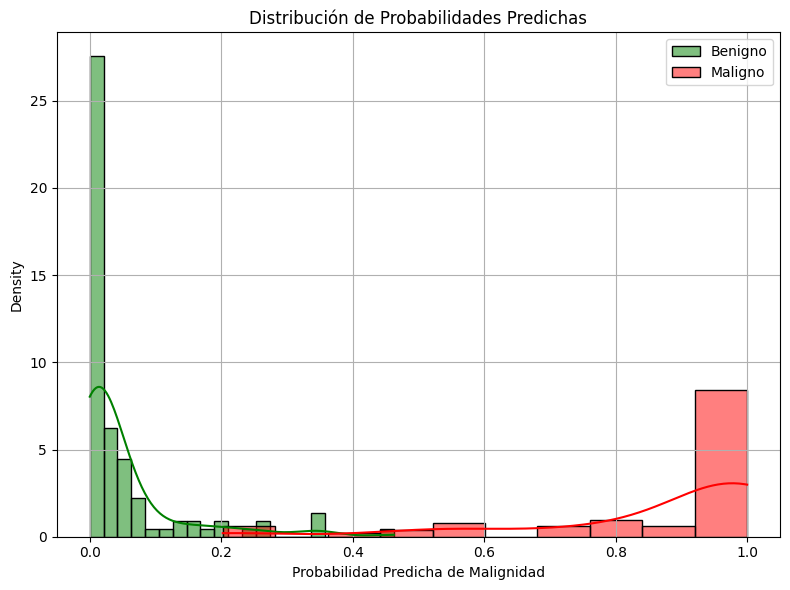

In [ ]:
y_probs = best_rf.predict_proba(X_test_class_scaled)[:, 1]

plt.figure(figsize=(8,6))
sns.histplot(y_probs[y_test_class==0], color="green", label="Benigno", kde=True, stat="density", alpha=0.5)
sns.histplot(y_probs[y_test_class==1], color="red", label="Maligno", kde=True, stat="density", alpha=0.5)
plt.xlabel("Probabilidad Predicha de Malignidad")
plt.title("Distribución de Probabilidades Predichas")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



La mayoría de los casos benignos tienen probabilidades predichas cercanas a 0, lo que indica que el modelo los clasifica correctamente con alta confianza.

La mayoría de los casos malignos tienen probabilidades predichas cercanas a 1, lo que también indica una clasificación correcta y confiada.

La separación clara entre ambas distribuciones sugiere que el modelo tiene un excelente poder discriminativo.